### Dust Reddening between BAL Quasars and Non-BAL Quasars

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LineLocking_FinalVersion as LineLocking
from astropy.table import Table
from tqdm.notebook import tqdm
from multiprocessing import Pool
import os
from astropy import units as u
import astropy.constants as const
import pandas as pd
from scipy.integrate import trapezoid
from scipy.signal import medfilt
from matplotlib.ticker import AutoMinorLocator
from matplotlib import rc
rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
rc('text', usetex=True)

from sklearn import preprocessing
from sklearn.cluster import KMeans


#### Set file paths and read in the trough table

In [2]:
species = 'CIV'
blue_line = 1548.20
red_line = 1550.77

# Load the table from the FITS file
Quasar_table = Table.read("Data/DR16Q_v4.fits", hdu=1)
column_names = ['PLATE', 'FIBERID', 'MJD', 'BAL_PROB', 'Z_PCA']
# Keep only required columns and convert to pandas
Quasar_table = Quasar_table[column_names].to_pandas()

# path to spectra
specdir = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/dr16Q/spectra/lite/'
# path to the trough file
trough_cat =  '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/'+species+'_trough_catalog_N'
# catalog containing the PCA information
balfilename = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/PCA_files/DR16Q_BAL_CIV.fits'
# eigenvectors
pcaeigenfile = '/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/PCA_files/PCA_Eigenvectors_Brodzeller.fits'


BALtrough_table = Table.read(trough_cat, hdu=1)
BALtrough_table = BALtrough_table.to_pandas()
BALtrough_table = BALtrough_table[BALtrough_table['PCA_CHI2'] <5.] 
BALtrough_table = BALtrough_table[BALtrough_table['SN_MEDIAN_ALL'] > 2.]
BALtrough_table = BALtrough_table[BALtrough_table['SDSS_CHI2'] <10.]
BALtrough_table = BALtrough_table[BALtrough_table['BAL_PROB'] > 0.8]
print (BALtrough_table.shape)


# cluster0_info = pd.read_parquet("/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cluster0_data.parquet")
# cluster1_info = pd.read_parquet("/Users/bradengail/Documents/Graduate_School/Projects/Line_Locking/Data/Cluster1_data.parquet")
clustered_data = pd.read_csv("./results_clustered.csv")
cluster0_info = clustered_data[clustered_data['cluster'] == 0]
cluster1_info = clustered_data[clustered_data['cluster'] == 1]
cluster2_info = clustered_data[clustered_data['cluster'] == -1]



# Assign clusters by matching DataFrame indices
cluster0_thingIDs = set(cluster0_info['Thing ID'])
cluster1_thingIDs = set(cluster1_info['Thing ID'])

# Add an empty 'Cluster' column initialized to -1 (unassigned)
BALtrough_table['Cluster'] = -1

for i, row in BALtrough_table.iterrows():
    if int(row['THING_ID']) in cluster0_thingIDs:
        BALtrough_table.at[i, 'Cluster'] = 0
    elif int(row['THING_ID']) in cluster1_thingIDs:
        BALtrough_table.at[i, 'Cluster'] = 1


(116428, 21)


#### Select desired troughs from the catalog

In [3]:
BAL_table_cluster0 = BALtrough_table[BALtrough_table['Cluster'] == 0]
BAL_table_cluster1 = BALtrough_table[BALtrough_table['Cluster'] == 1]
nonBAL_table = Quasar_table[Quasar_table['BAL_PROB'] == 0]

#### find and rebin all spectra from a trough table so that they can later be stacked

In [4]:
def get_spectra_from_table(trough_table, BAL_Table=False):
    rejection_counter = 0
    c = const.c.value / 1000  # km/s
    rebin_wavelengths = np.arange(600.2, 2799.8)
    spectra_2be_stacked = []

    # Copy table to avoid modifying original
    trough_table = trough_table.copy()
    trough_table["SPECNAME"] = trough_table.apply(
        lambda row: LineLocking.determine_spec_fileName(row, specdir), axis=1
    )

    grouped = trough_table.groupby("SPECNAME")

    for specname, group in tqdm(grouped):
        try:
            current_spec_data = LineLocking.read_spec(specname)
        except Exception:
            continue  # Skip this group if reading fails

        z = group.iloc[0]['Z_PCA']
        x = current_spec_data['WAVE_OBS'].values / (1. + z)
        y = current_spec_data['FLUX'].values

        current_sky_flag = LineLocking.find_sky_line(current_spec_data['WAVE_OBS'])
        rebin_sky_flag = np.interp(rebin_wavelengths, x, current_sky_flag)
        rebin_sky_flag[np.where(rebin_sky_flag > 0.01)] = 1

        rebin_flux = np.full_like(rebin_wavelengths, np.nan, dtype=float)
        mask = (rebin_wavelengths >= x.min()) & (rebin_wavelengths <= x.max())
        rebin_flux[mask] = np.interp(rebin_wavelengths[mask], x, y)

        norm_mask = (rebin_wavelengths > 2000) & (rebin_wavelengths < 2200)
        flux_subset = rebin_flux[norm_mask]
        valid_flux = flux_subset[~np.isnan(flux_subset)]

        if len(valid_flux) > 30:
            median_flux = np.median(valid_flux)
            corrected_flux = rebin_flux / median_flux

            if BAL_Table:
                lines = [1548.20, 1238.821, 1215.670, 1031.926, 1393.755]  # CIV, NV, HI, OVI, SiIV

                for _, row in group.iterrows():
                    z_min = row['Z_MIN']
                    vmin = row['VMIN']
                    vmax = row['VMAX']
                    posmin = row['POSMIN']

                    for line in lines:
                        # Step 1: Compute trough limits in the *trough rest frame*
                        wl_trough_lower_rest = line * (1 - ((vmax - posmin) / c))
                        wl_trough_upper_rest = line * (1 + ((posmin - vmin) / c))

                        # Step 2: Convert limits back to *quasar rest frame*
                        wl_trough_lower = wl_trough_lower_rest * (1 + z_min)/(1 + z)
                        wl_trough_upper = wl_trough_upper_rest * (1 + z_min)/(1 + z)

                        # Step 3: Find bounds in the quasar rest frame wavelength array
                        lower_idx = np.argmin(np.abs(rebin_wavelengths - wl_trough_lower))
                        if rebin_wavelengths[lower_idx] < wl_trough_lower:
                            lower_idx += 1

                        upper_idx = np.argmin(np.abs(rebin_wavelengths - wl_trough_upper))
                        if rebin_wavelengths[upper_idx] > wl_trough_upper:
                            upper_idx -= 1

                        # Step 4: Mask the flux
                        corrected_flux[lower_idx:upper_idx] = np.nan

            corrected_flux[np.where(rebin_sky_flag == 1)] = np.nan


            if np.any(~np.isnan(corrected_flux)):
                spectra_2be_stacked.append(corrected_flux)
            else:
                rejection_counter +=1
        else:
            rejection_counter +=1


    return spectra_2be_stacked, rejection_counter


In [5]:
BAL_Cluster0_Spectra, BAL_Cluster0_reject = get_spectra_from_table(BAL_table_cluster0, BAL_Table=True)
BAL_Cluster1_Spectra, BAL_Cluster1_reject = get_spectra_from_table(BAL_table_cluster1, BAL_Table=True)

nonBAL_Spectra, nonBALreject  = get_spectra_from_table(nonBAL_table)

  0%|          | 0/10625 [00:00<?, ?it/s]

  0%|          | 0/1741 [00:00<?, ?it/s]

  0%|          | 0/313735 [00:00<?, ?it/s]

#### Stack the spectra and plot

/var/folders/b9/j3sh3wq91237z_qzrkn1vmv80000gn/T/ipykernel_71049/1543309904.py:91: MatplotlibDeprecationWarning: Since Matplotlib 3.10 indicate_inset_[zoom] returns a single InsetIndicator artist with a rectangle property and a connectors property.  From 3.12 it will no longer be possible to unpack the return value into two elements.
  _, connectors = ax.indicate_inset_zoom(axins, edgecolor='black', linewidth=1.2,
/var/folders/b9/j3sh3wq91237z_qzrkn1vmv80000gn/T/ipykernel_71049/1543309904.py:98: RuntimeWarning: invalid value encountered in log10
  axes[1].plot(wls_filtered, -2.5*np.log10(BALcluster1_Stack / nonBAL_Stack), color='darkorange')
/var/folders/b9/j3sh3wq91237z_qzrkn1vmv80000gn/T/ipykernel_71049/1543309904.py:99: RuntimeWarning: invalid value encountered in log10
  axes[1].plot(wls_filtered, -2.5*np.log10(BALcluster0_Stack / nonBAL_Stack), color='forestgreen')


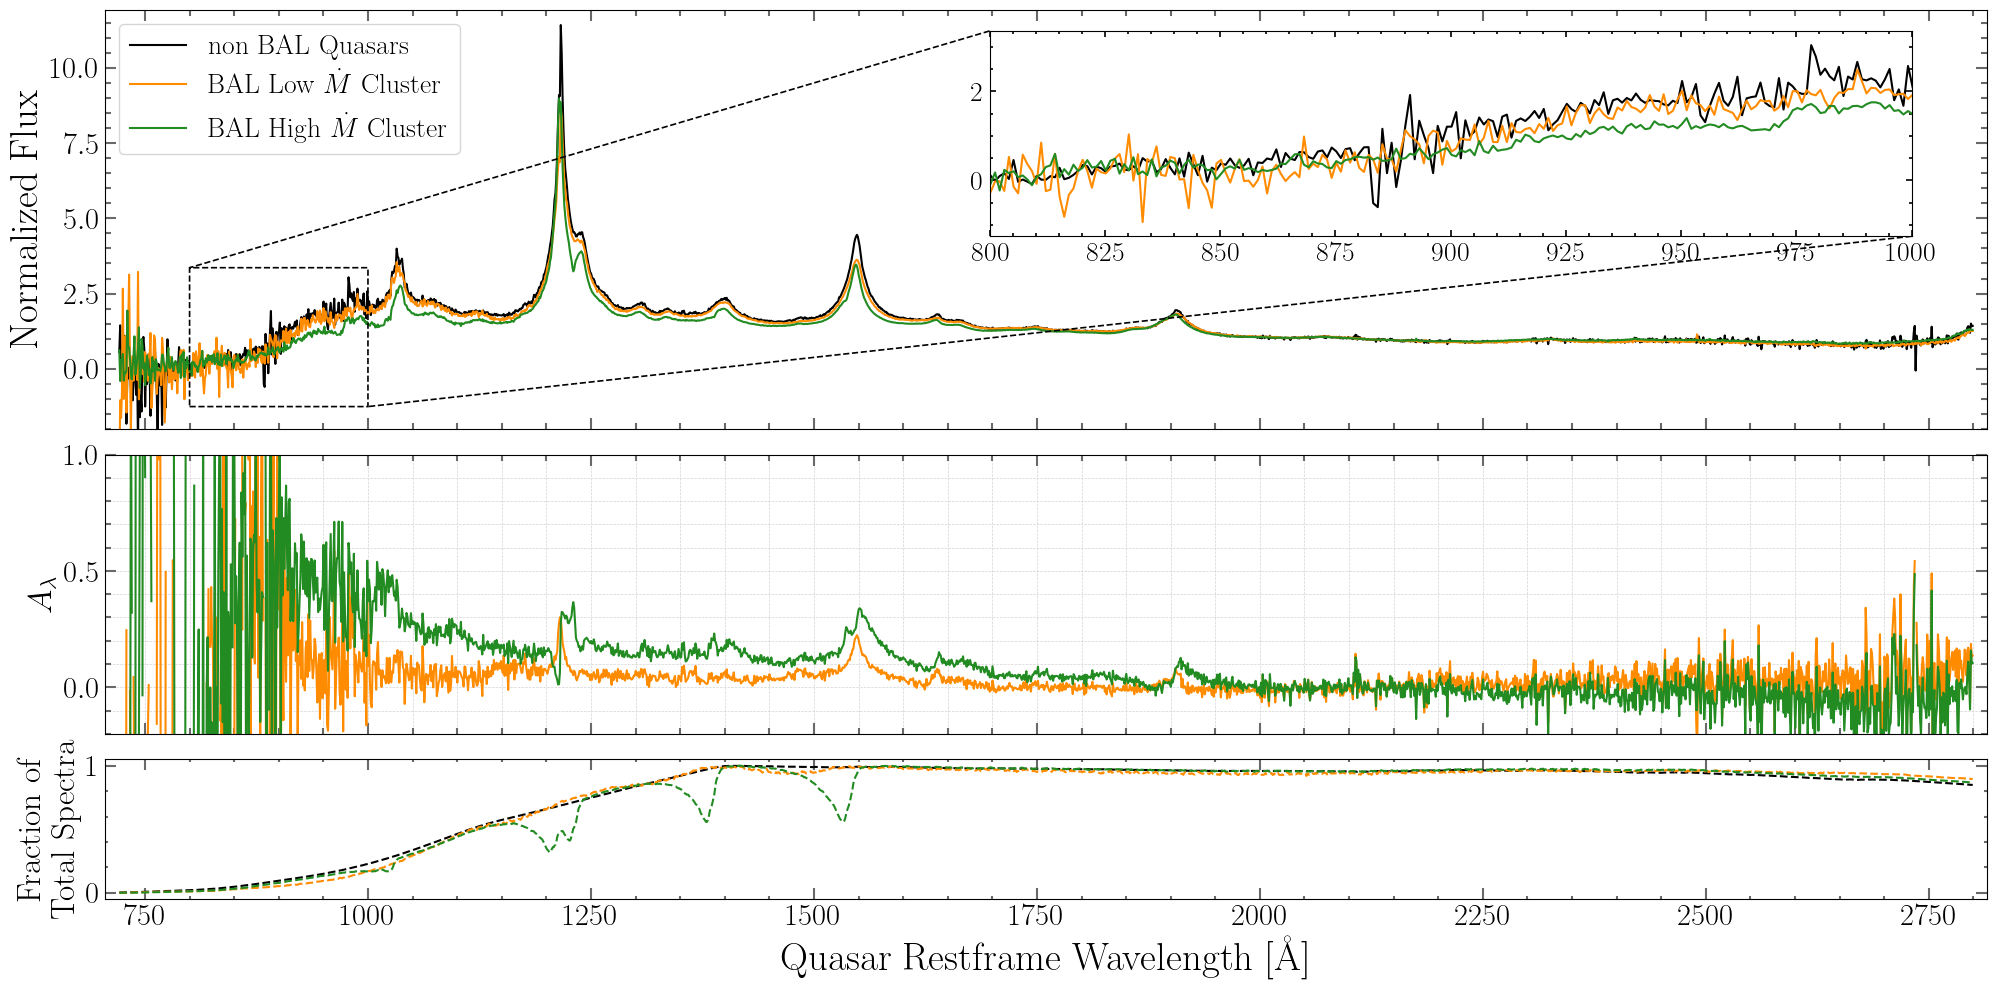

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch

# Wavelengths
wls = np.arange(600.2, 2799.8)

# Stack arrays
nonBAL_array = np.vstack(nonBAL_Spectra)
BALcluster0_array = np.vstack(BAL_Cluster0_Spectra)
BALcluster1_array = np.vstack(BAL_Cluster1_Spectra)

# Identify valid columns where at least one value is finite in all stacks
nonBAL_mask    = np.any(np.isfinite(nonBAL_array),    axis=0)
BALcluster0_mask = np.any(np.isfinite(BALcluster0_array), axis=0)
BALcluster1_mask = np.any(np.isfinite(BALcluster1_array), axis=0)
valid_mask = nonBAL_mask & BALcluster0_mask & BALcluster1_mask

# Filter before stacking
nonBAL_array_filtered    = nonBAL_array[:,    valid_mask]
BALcluster0_array_filtered = BALcluster0_array[:, valid_mask]
BALcluster1_array_filtered = BALcluster1_array[:, valid_mask]
wls_filtered = wls[valid_mask]

# Compute means
nonBAL_Stack    = np.nanmean(nonBAL_array_filtered,    axis=0)
BALcluster0_Stack = np.nanmean(BALcluster0_array_filtered, axis=0)
BALcluster1_Stack = np.nanmean(BALcluster1_array_filtered, axis=0)

# Count non-NaN points, normalised to max
nonBAL_counts = np.sum(np.isfinite(nonBAL_array_filtered), axis=0)
nonBAL_counts = nonBAL_counts / np.max(nonBAL_counts)

BALcluster0_counts = np.sum(np.isfinite(BALcluster0_array_filtered), axis=0)
BALcluster0_counts = BALcluster0_counts / np.max(BALcluster0_counts)

BALcluster1_counts = np.sum(np.isfinite(BALcluster1_array_filtered), axis=0)
BALcluster1_counts = BALcluster1_counts / np.max(BALcluster1_counts)

# ── PLOT ─────────────────────────────────────────────────────────────────────
labelsize = 28
ticksize  = 24

fig, axes = plt.subplots(3, 1, figsize=(20, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 2, 1]})

# ── Top panel: stacked spectra ───────────────────────────────────────────────
ax = axes[0]
ax.plot(wls_filtered, nonBAL_Stack,    color='black',       label='non BAL Quasars')
ax.plot(wls_filtered, BALcluster1_Stack, color='darkorange', label='BAL Low $\\dot{M}$ Cluster')
ax.plot(wls_filtered, BALcluster0_Stack, color='forestgreen', label=r'BAL High $\dot{M}$ Cluster')
ax.set_ylabel(r"Normalized Flux", fontsize=labelsize)
ax.tick_params(axis='both', which='major', direction='in', top=True, right=True,
               length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
               length=4, width=1.5, color='dimgrey')
ax.minorticks_on()
ax.legend(fontsize=labelsize-8, loc='upper left')
ax.set_ylim(-2, np.max(nonBAL_Stack) + 0.5)

# ── Inset: zoom into 800–1000 Å ─────────────────────────────────────────────
# Position in axes-fraction coords: [left, bottom, width, height]
# Sits in the upper-right, clear of the legend in the upper-left
axins = ax.inset_axes([0.47, 0.46, 0.49, 0.49])

axins.plot(wls_filtered, nonBAL_Stack,    color='black')
axins.plot(wls_filtered, BALcluster1_Stack, color='darkorange')
axins.plot(wls_filtered, BALcluster0_Stack, color='forestgreen')

# Zoom window
zoom_x1, zoom_x2 = 800, 1000
zoom_mask = (wls_filtered >= zoom_x1) & (wls_filtered <= zoom_x2)
y_zoom = np.concatenate([nonBAL_Stack[zoom_mask],
                         BALcluster1_Stack[zoom_mask],
                         BALcluster0_Stack[zoom_mask]])
y_zoom = y_zoom[np.isfinite(y_zoom)]
y_pad  = (y_zoom.max() - y_zoom.min()) * 0.08
axins.set_xlim(zoom_x1, zoom_x2)
axins.set_ylim(y_zoom.min() - y_pad, y_zoom.max() + y_pad)

axins.tick_params(axis='both', which='major', direction='in', top=True, right=True,
                  length=4, width=1.2, labelsize=ticksize-4, pad=4)
axins.tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                  length=2, width=1.2)
axins.minorticks_on()

# Draw zoom box + connectors manually so we can control exactly which corners connect.
# indicate_inset_zoom returns (box_patch, connector_lines) — connectors order is
# [bottom-left, top-left, bottom-right, top-right]; we enable only top-left (1) and bottom-right (2).
_, connectors = ax.indicate_inset_zoom(axins, edgecolor='black', linewidth=1.2,
                                        alpha=1, linestyle='--')
# connectors: 0=bottom-left, 1=top-left, 2=bottom-right, 3=top-right
for i, con in enumerate(connectors):
    con.set_visible(i in (1, 2))  # show only top-left and bottom-right

# ── Middle panel: attenuation ────────────────────────────────────────────────
axes[1].plot(wls_filtered, -2.5*np.log10(BALcluster1_Stack / nonBAL_Stack), color='darkorange')
axes[1].plot(wls_filtered, -2.5*np.log10(BALcluster0_Stack / nonBAL_Stack), color='forestgreen')
axes[1].set_ylim(-0.2, 1)
axes[1].set_ylabel(r"$A_{\lambda}$", fontsize=labelsize-4)
axes[1].tick_params(axis='both', which='major', direction='in', top=True, right=True,
                    length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
axes[1].tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                    length=4, width=1.5, color='dimgrey')
axes[1].grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, color='lightgrey')
axes[1].minorticks_on()

# ── Bottom panel: coverage fraction ─────────────────────────────────────────
axes[2].plot(wls_filtered, nonBAL_counts,    color='black',       linestyle='--')
axes[2].plot(wls_filtered, BALcluster1_counts, color='darkorange', linestyle='--')
axes[2].plot(wls_filtered, BALcluster0_counts, color='forestgreen', linestyle='--')
axes[2].set_ylabel("Fraction of \n Total Spectra", fontsize=labelsize-4)
axes[2].tick_params(axis='both', which='major', direction='in', top=True, right=True,
                    length=8, width=1.5, labelsize=ticksize-2, color='dimgrey')
axes[2].tick_params(axis='both', which='minor', direction='in', top=True, right=True,
                    length=2, width=1.5, color='dimgrey')
axes[2].minorticks_on()
axes[2].set_xlabel(r'Quasar Restframe Wavelength [$\mathrm{\AA}$]', fontsize=labelsize)

plt.xlim(np.min(wls_filtered) - 16, np.max(wls_filtered) + 16)
plt.tight_layout()
plt.savefig("Results/Figures/Dust_Reddening.png", bbox_inches="tight", dpi=300)
plt.show()

## Now Calculate the Normalized Flux difference between clusters and non-BAL samples

In [11]:
from numpy import trapezoid

# Integrate each curve
area_nonBAL = trapezoid(nonBAL_Stack, x=wls_filtered)
area_BAL0 = trapezoid(BALcluster0_Stack, x=wls_filtered)
area_BAL1 = trapezoid(BALcluster1_Stack, x=wls_filtered)

# Percent differences
diff_BAL0 = 100 * 0.38*(area_nonBAL-area_BAL0) / area_nonBAL
diff_BAL1 = 100 * 0.38*(area_nonBAL-area_BAL1) / area_nonBAL

print(f"Integrated area (nonBAL): {area_nonBAL:.4f}")
print(f"Integrated area (BAL Cluster 0): {area_BAL0:.4f} → {diff_BAL0:.2f}% difference from nonBAL")
print(f"Integrated area (BAL Cluster 1): {area_BAL1:.4f} → {diff_BAL1:.2f}% difference from nonBAL")


Integrated area (nonBAL): 2940.5485
Integrated area (BAL Cluster 0): 2657.3298 → 3.66% difference from nonBAL
Integrated area (BAL Cluster 1): 2804.9253 → 1.75% difference from nonBAL
